# 📊 VCGC vs SAHA-BELLETTI Flow
This is a draft to compare the performance on my proposed flow, VCGC, to the state-of-the-art flow, Saha-Belleti et al.
I would be comparing documenting and comparing the differences in the my proposed flow and the SOTA flow. 
VCGC is primarily based on the idea of using state-of-the-art logic synthesis and reversible circuit logic with a layered approach that opens room for optimizations.
Saha-Belletti et al. proposed flow is based on a monolothic architecture which uses invalid-color-detector and comparator oracles.   

## 📦 Packages
For the pupose of this research study, I independently developed and implemented the library for VCGC and repurposed the open-source code provided by [Analyzing, Fixing and Optimizing a Space-Efficient Quantum Circuit for the Graph K-Coloring Problem](https://github.com/Oscar-Belletti/Analyzing-Fixing-and-Optimizing-a-Space-Efficient-Quantum-Circuit-for-the-Graph-K-Coloring-Problem) by converting into a re-usable python library. _These libraries are essential in automating the synthesis of the circuits and generation of benchmark results._


### 1. Creating a Vertex Coloring Problem Network (VCP)
This will read from the DIMACS.col files which contain the benchamrks and parse it to be a VCPNetwork object which contains the metadata of the graph and a NetworkX representation of the graph. This will serve as the input to both of the libraries.

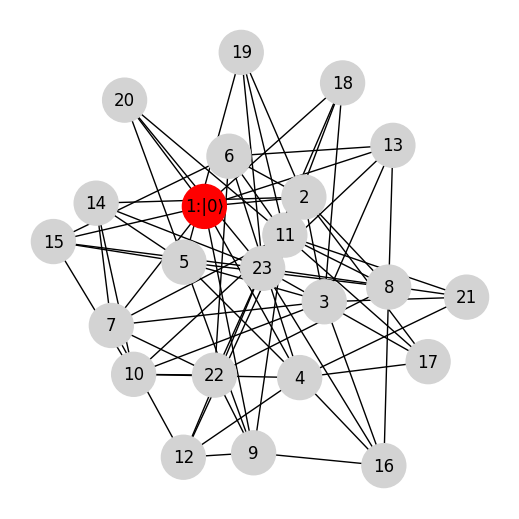

In [131]:
from vcgc.network import VCPNetwork
from IPython.display import display

draw_circuits: bool = False
out_dir: str = "../data/vcgc_vs_saha_belletti/"
filename: str = "myciel4"
dimacs_filename: str = "../data/benchmarks/" + filename + ".col"

network = VCPNetwork(file_path=dimacs_filename)

graph_filename: str = out_dir + filename + ".png"
with open(graph_filename,"w+") as f:
    f.close()
    
# Display the graph
network.draw_graph(name=graph_filename, node_size=1000) # Draw nice graph using NetworkX

### 2. Grover Circuit Synthesis using VCGC
This will prepare the complete grover's circuit using the VCGC library.

#### 2.1 Extract the graph constraints

In [132]:
from vcgc.boolean import BooleanFunction

# Create Boolean function and display the constraints 
bf: BooleanFunction  = BooleanFunction()
bf.print_vertex_constraints(network=network)

(v1 != v2) ∧ (v1 != v4) ∧ (v1 != v7) ∧ (v1 != v9) ∧ (v1 != v13) ∧ (v1 != v15) ∧ (v1 != v18) ∧ (v1 != v20) ∧ (v2 != v3) ∧ (v2 != v6) ∧ (v2 != v8) ∧ (v2 != v12) ∧ (v2 != v14) ∧ (v2 != v17) ∧ (v2 != v19) ∧ (v3 != v5) ∧ (v3 != v7) ∧ (v3 != v10) ∧ (v3 != v13) ∧ (v3 != v16) ∧ (v3 != v18) ∧ (v3 != v21) ∧ (v4 != v5) ∧ (v4 != v6) ∧ (v4 != v10) ∧ (v4 != v12) ∧ (v4 != v16) ∧ (v4 != v17) ∧ (v4 != v21) ∧ (v5 != v8) ∧ (v5 != v9) ∧ (v5 != v14) ∧ (v5 != v15) ∧ (v5 != v19) ∧ (v5 != v20) ∧ (v6 != v11) ∧ (v6 != v13) ∧ (v6 != v15) ∧ (v6 != v22) ∧ (v7 != v11) ∧ (v7 != v12) ∧ (v7 != v14) ∧ (v7 != v22) ∧ (v8 != v11) ∧ (v8 != v13) ∧ (v8 != v16) ∧ (v8 != v22) ∧ (v9 != v11) ∧ (v9 != v12) ∧ (v9 != v16) ∧ (v9 != v22) ∧ (v10 != v11) ∧ (v10 != v14) ∧ (v10 != v15) ∧ (v10 != v22) ∧ (v11 != v17) ∧ (v11 != v18) ∧ (v11 != v19) ∧ (v11 != v20) ∧ (v11 != v21) ∧ (v12 != v23) ∧ (v13 != v23) ∧ (v14 != v23) ∧ (v15 != v23) ∧ (v16 != v23) ∧ (v17 != v23) ∧ (v18 != v23) ∧ (v19 != v23) ∧ (v20 != v23) ∧ (v21 != v23) ∧ (v22 != v23)



#### 2.2 Generate the corresponding Logic Network

In [133]:
from tweedledum.bool_function_compiler.bool_function import BoolFunction
from tweedledum.classical import write_gate_dot, LogicNetwork
from graphviz import Source

# Generate tweedledum boolean function
tweedledum_bf: BoolFunction = bf.create_multi_bit_function(network=network)
logic_network: LogicNetwork = tweedledum_bf.logic_network()

# Write to Verilog
verilog_filename: str = out_dir + filename + ".v"
bf.write_verilog_file(network=network, filename=verilog_filename)

dot_filename: str = out_dir + filename + ".dot"

# Create a file with filename if it does not exist
with open(file=dot_filename, mode="w+") as f:
    f.close()

write_gate_dot(logic_network, dot_filename)

# Read and display the dot file
with open(dot_filename, 'r') as f:
    dot_content = f.read()

# Create and display the graph
graph = Source(dot_content)
# graph.view()  # This will open in external viewer
# display(graph)  # This will display inline in Jupyter notebook

Verilog file written to: ../data/vcgc_vs_saha_belletti/myciel4.v


#### 2.3 Set up XAG Synthesizer

In [134]:
from vcgc.synthesis import Synthesizer

synthesizer: Synthesizer = Synthesizer(cf=tweedledum_bf)

#### 2.4 Synthesize with XAG

In [135]:
from qiskit import QuantumCircuit

oracle_circuit_xag: QuantumCircuit = synthesizer.synthesize_with_xag()
# To output the circuit as ASCII art:
synthesizer.print_circuit_info()


Number of qubits: 281
                                                                           »
__a280 : ──────────────────────────────────────────────────────────────────»
                                                                           »
__a279 : ──────────────────────────────────────────────────────────────────»
                                                                           »
__a278 : ──────────────────────────────────────────────────────────────────»
                                                                           »
__a277 : ──────────────────────────────────────────────────────────────────»
                                                                           »
__a276 : ──────────────────────────────────────────────────────────────────»
                                                                           »
__a275 : ──────────────────────────────────────────────────────────────────»
                                                      

#### 2.5 Display and Save the oracle circuit

In [136]:
from qiskit.qasm3 import dump
qasm_filename: str = out_dir + filename + ".qasm"
with open(qasm_filename,"w") as f:
        dump(circuit=synthesizer.qiskit_circuit, stream=f)
# oracle_circuit_xag.draw("mpl")

#### 2.6 Create Uniform Superposition State Preparation Oracle to Filter Out Invalid Encodings

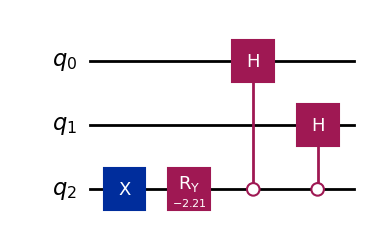

In [137]:
from vcgc.circuit import uniform_superposition_qiskit
from math import ceil, log2

num_superpos_states: int = network.available_colors
num_encode_qubits: int = ceil(log2(num_superpos_states)) # Leaving this here just for reference, it is done automatically
usp_oracle: QuantumCircuit = uniform_superposition_qiskit(num_superpos_states=num_superpos_states).decompose()

usp_oracle.draw(output="mpl")

#### 2.7 Verify the Uniform Distribution Through Analyzing the StateVector

In [138]:

from qiskit_aer import AerSimulator
from qiskit import transpile
import numpy as np

# Create statevector simulator
statevector_sim = AerSimulator(method='statevector')

# Run without measurement to get the statevector
qc_no_measurement = usp_oracle.copy()
qc_no_measurement.save_statevector()
compiled_sv_circuit = transpile(qc_no_measurement, statevector_sim)
job_sv = statevector_sim.run(compiled_sv_circuit)
result_sv = job_sv.result()
# Get the statevector
statevector = result_sv.get_statevector()

# Print amplitudes for each computational basis state
print("\nStatevector amplitudes:")
for i, amplitude in enumerate(statevector):
    if abs(amplitude) > 1e-10:  # Only show non-zero amplitudes
        probability = abs(amplitude)**2
        print(f"|{i:0{num_encode_qubits}b}⟩: amplitude = {amplitude:.4f}, probability = {probability:.4f}")

# Verify uniform distribution
expected_amplitude = 1/np.sqrt(num_superpos_states)
print(f"\nExpected amplitude for each state: {expected_amplitude:.4f}")
print(f"Expected probability for each state: {expected_amplitude**2:.4f}")


Statevector amplitudes:
|000⟩: amplitude = 0.4472-0.0000j, probability = 0.2000
|001⟩: amplitude = 0.4472+0.0000j, probability = 0.2000
|010⟩: amplitude = 0.4472+0.0000j, probability = 0.2000
|011⟩: amplitude = 0.4472+0.0000j, probability = 0.2000
|100⟩: amplitude = 0.4472-0.0000j, probability = 0.2000

Expected amplitude for each state: 0.4472
Expected probability for each state: 0.2000


/var/folders/tk/swjmm3f51fqbfbkckfb9cddm0000gn/T/ipykernel_71835/3774968417.py:19: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  for i, amplitude in enumerate(statevector):


#### 2.8 Create the Respective Diffusion Operator

In [139]:
from vcgc.circuit import generate_grover_diffusion

num_data_qubits: int = network.num_vertices * num_encode_qubits
diff_oracle: QuantumCircuit = generate_grover_diffusion(num_qubits=num_data_qubits, uqs=usp_oracle)
# display(diff_oracle.draw(output="mpl"))

#### 2.9 Glue the Complete Grover Circuit Together

In [140]:
from vcgc.circuit import glue_grover_circuit
# Create the complete Grover circuit
vcgc_grover_circuit: QuantumCircuit = glue_grover_circuit(
    usp=usp_oracle,
    oracle=oracle_circuit_xag,
    diffusion=diff_oracle,
    num_data_qubits=num_data_qubits,
    num_encode_qubits=num_encode_qubits
)

# Display circuit information
print(f"`VCGC` Grover Circuit:")
print(f"Total qubits: {vcgc_grover_circuit.num_qubits}")
print(f"Circuit depth: {vcgc_grover_circuit.depth()}")
print(f"Number of gates: {len(vcgc_grover_circuit)}")

# Draw the circuit (might be large for complex graphs)
# display(vcgc_grover_circuit.draw(output="mpl"))

`VCGC` Grover Circuit:
Total qubits: 281
Circuit depth: 192
Number of gates: 1696


### 3. Grover Circuit Synthesis using the methodology in Saha et al. and Belletti et al. papers.
This will prepare the complete grover's circuit using the saha-belletti library.

#### 3.1 Synthesize the `original` circuit

In [141]:
from saha_belletti.core import generate_circuit

# Generate Saha-Belleti Circuits
sb_original_grover_circuit: QuantumCircuit = generate_circuit(graph=network.graph, colors=network.available_colors, oracle_type='original', grover_iterations=1) # grover_iterations

# Display circuit information
print(f"Saha-Belletti `original` Grover Circuit:")
print(f"Total qubits: {sb_original_grover_circuit.num_qubits}")
print(f"Circuit depth: {sb_original_grover_circuit.depth()}")
print(f"Number of gates: {len(sb_original_grover_circuit)}")

# Draw the circuit (might be large for complex graphs)
# if draw_circuits:
# display(sb_original_grover_circuit.draw(output="mpl"))

Grover iterations: 1
Saha-Belletti `original` Grover Circuit:
Total qubits: 96
Circuit depth: 1186
Number of gates: 4256


In [142]:
# Count ancilla qubits needed for MCX decomposition using dirty ancilla

def count_ancilla_for_mcx_decomposition(circuit, exclude_diffusion=True):
    total_ancilla_needed = 0
    mcx_gates_info = []
    
    # Find all MCX gates first
    mcx_instructions = []
    for instruction in circuit.data:
        if instruction.operation.name == 'mcx':
            mcx_instructions.append(instruction)
    
    # If excluding diffusion, remove the last MCX gate (assumed to be from diffusion)
    if exclude_diffusion and len(mcx_instructions) > 0:
        mcx_instructions = mcx_instructions[:-1]  # Remove last MCX gate
    
    # Process the remaining MCX gates
    for instruction in mcx_instructions:
        num_controls = len(instruction.qubits) - 1  # All qubits except target
        ancilla_needed = max(0, num_controls - 2)
        total_ancilla_needed = total_ancilla_needed + ancilla_needed
        mcx_gates_info.append((num_controls, ancilla_needed))
    
    return total_ancilla_needed, mcx_gates_info

# Calculate for Saha-Belletti original circuit
ancilla_needed, mcx_info = count_ancilla_for_mcx_decomposition(sb_original_grover_circuit)

print(f"Saha-Belletti `original` circuit MCX analysis:")
print(f"Total MCX gates: {len(mcx_info)}")
print(f"Maximum ancilla qubits needed for decomposition: {ancilla_needed}")
print(f"MCX gates breakdown (controls, ancilla_needed):")
for i, (controls, ancilla) in enumerate(mcx_info):
    print(f"  MCX gate {i+1}: {controls} controls, {ancilla} ancilla needed")

print(f"\nOriginal circuit qubits: {sb_original_grover_circuit.num_qubits}")
print(f"Total qubits after MCX decomposition: {sb_original_grover_circuit.num_qubits + ancilla_needed}")

Saha-Belletti `original` circuit MCX analysis:
Total MCX gates: 545
Maximum ancilla qubits needed for decomposition: 742
MCX gates breakdown (controls, ancilla_needed):
  MCX gate 1: 3 controls, 1 ancilla needed
  MCX gate 2: 3 controls, 1 ancilla needed
  MCX gate 3: 3 controls, 1 ancilla needed
  MCX gate 4: 3 controls, 1 ancilla needed
  MCX gate 5: 3 controls, 1 ancilla needed
  MCX gate 6: 3 controls, 1 ancilla needed
  MCX gate 7: 3 controls, 1 ancilla needed
  MCX gate 8: 3 controls, 1 ancilla needed
  MCX gate 9: 3 controls, 1 ancilla needed
  MCX gate 10: 3 controls, 1 ancilla needed
  MCX gate 11: 3 controls, 1 ancilla needed
  MCX gate 12: 3 controls, 1 ancilla needed
  MCX gate 13: 3 controls, 1 ancilla needed
  MCX gate 14: 3 controls, 1 ancilla needed
  MCX gate 15: 3 controls, 1 ancilla needed
  MCX gate 16: 3 controls, 1 ancilla needed
  MCX gate 17: 3 controls, 1 ancilla needed
  MCX gate 18: 3 controls, 1 ancilla needed
  MCX gate 19: 3 controls, 1 ancilla needed
  MC

#### 3.2 Synthesize the `minimal` circuit

In [143]:
# Generate Saha-Belleti Circuits
sb_minimal_grover_circuit: QuantumCircuit = generate_circuit(graph=network.graph, colors=network.available_colors, oracle_type='minimal', grover_iterations=1) # grover_iterations

# Display circuit information
print(f"Saha-Belletti `minimal` Grover Circuit:")
print(f"Total qubits: {sb_minimal_grover_circuit.num_qubits}")
print(f"Circuit depth: {sb_minimal_grover_circuit.depth()}")
print(f"Number of gates: {len(sb_minimal_grover_circuit)}")

# Draw the circuit (might be large for complex graphs)
if draw_circuits:
    display(sb_minimal_grover_circuit.draw(output="mpl"))

Grover iterations: 1
Saha-Belletti `minimal` Grover Circuit:
Total qubits: 79
Circuit depth: 7890
Number of gates: 53391


In [144]:
# Calculate for Saha-Belletti original circuit
ancilla_needed, mcx_info = count_ancilla_for_mcx_decomposition(sb_minimal_grover_circuit)

print(f"Saha-Belletti `original` circuit MCX analysis:")
print(f"Total MCX gates: {len(mcx_info)}")
print(f"Maximum ancilla qubits needed for decomposition: {ancilla_needed}")
print(f"MCX gates breakdown (controls, ancilla_needed):")
for i, (controls, ancilla) in enumerate(mcx_info):
    print(f"  MCX gate {i+1}: {controls} controls, {ancilla} ancilla needed")

print(f"\nOriginal circuit qubits: {sb_minimal_grover_circuit.num_qubits}")
print(f"Total qubits after MCX decomposition: {sb_minimal_grover_circuit.num_qubits + ancilla_needed}")

Saha-Belletti `original` circuit MCX analysis:
Total MCX gates: 6423
Maximum ancilla qubits needed for decomposition: 6667
MCX gates breakdown (controls, ancilla_needed):
  MCX gate 1: 3 controls, 1 ancilla needed
  MCX gate 2: 3 controls, 1 ancilla needed
  MCX gate 3: 3 controls, 1 ancilla needed
  MCX gate 4: 3 controls, 1 ancilla needed
  MCX gate 5: 3 controls, 1 ancilla needed
  MCX gate 6: 3 controls, 1 ancilla needed
  MCX gate 7: 3 controls, 1 ancilla needed
  MCX gate 8: 3 controls, 1 ancilla needed
  MCX gate 9: 3 controls, 1 ancilla needed
  MCX gate 10: 3 controls, 1 ancilla needed
  MCX gate 11: 3 controls, 1 ancilla needed
  MCX gate 12: 3 controls, 1 ancilla needed
  MCX gate 13: 3 controls, 1 ancilla needed
  MCX gate 14: 3 controls, 1 ancilla needed
  MCX gate 15: 3 controls, 1 ancilla needed
  MCX gate 16: 3 controls, 1 ancilla needed
  MCX gate 17: 3 controls, 1 ancilla needed
  MCX gate 18: 3 controls, 1 ancilla needed
  MCX gate 19: 3 controls, 1 ancilla needed
  

#### 3.3 Synthesize the `simple` circuit

In [145]:
# Generate Saha-Belleti Circuits
sb_simple_grover_circuit: QuantumCircuit = generate_circuit(graph=network.graph, colors=network.available_colors, oracle_type='simple', grover_iterations=1) # grover_iterations

# Display circuit information
print(f"Saha-Belletti `simple` Grover Circuit:")
print(f"Total qubits: {sb_simple_grover_circuit.num_qubits}")
print(f"Circuit depth: {sb_simple_grover_circuit.depth()}")
print(f"Number of gates: {len(sb_simple_grover_circuit)}")

# Draw the circuit (might be large for complex graphs)
# display(sb_simple_grover_circuit.draw(output="mpl"))

Grover iterations: 1
Saha-Belletti `simple` Grover Circuit:
Total qubits: 210
Circuit depth: 130
Number of gates: 2727


In [146]:
# Calculate for Saha-Belletti original circuit
ancilla_needed, mcx_info = count_ancilla_for_mcx_decomposition(sb_simple_grover_circuit)

print(f"Saha-Belletti `original` circuit MCX analysis:")
print(f"Total MCX gates: {len(mcx_info)}")
print(f"Maximum ancilla qubits needed for decomposition: {ancilla_needed}")
print(f"MCX gates breakdown (controls, ancilla_needed):")
for i, (controls, ancilla) in enumerate(mcx_info):
    print(f"  MCX gate {i+1}: {controls} controls, {ancilla} ancilla needed")

print(f"\nOriginal circuit qubits: {sb_simple_grover_circuit.num_qubits}")
print(f"Total qubits after MCX decomposition: {sb_simple_grover_circuit.num_qubits + ancilla_needed}")

Saha-Belletti `original` circuit MCX analysis:
Total MCX gates: 281
Maximum ancilla qubits needed for decomposition: 418
MCX gates breakdown (controls, ancilla_needed):
  MCX gate 1: 3 controls, 1 ancilla needed
  MCX gate 2: 3 controls, 1 ancilla needed
  MCX gate 3: 3 controls, 1 ancilla needed
  MCX gate 4: 3 controls, 1 ancilla needed
  MCX gate 5: 3 controls, 1 ancilla needed
  MCX gate 6: 3 controls, 1 ancilla needed
  MCX gate 7: 3 controls, 1 ancilla needed
  MCX gate 8: 3 controls, 1 ancilla needed
  MCX gate 9: 3 controls, 1 ancilla needed
  MCX gate 10: 3 controls, 1 ancilla needed
  MCX gate 11: 3 controls, 1 ancilla needed
  MCX gate 12: 3 controls, 1 ancilla needed
  MCX gate 13: 3 controls, 1 ancilla needed
  MCX gate 14: 3 controls, 1 ancilla needed
  MCX gate 15: 3 controls, 1 ancilla needed
  MCX gate 16: 3 controls, 1 ancilla needed
  MCX gate 17: 3 controls, 1 ancilla needed
  MCX gate 18: 3 controls, 1 ancilla needed
  MCX gate 19: 3 controls, 1 ancilla needed
  MC

#### 3.4 Synthesize the `balanced` circuit

In [147]:
# Generate Saha-Belleti Circuits
sb_balanced_grover_circuit: QuantumCircuit = generate_circuit(graph=network.graph, colors=network.available_colors, oracle_type='balanced', grover_iterations=1) # grover_iterations

# Display circuit information
print(f"Saha-Belletti `balanced` Grover Circuit:")
print(f"Total qubits: {sb_balanced_grover_circuit.num_qubits}")
print(f"Circuit depth: {sb_balanced_grover_circuit.depth()}")
print(f"Number of gates: {len(sb_balanced_grover_circuit)}")

# Draw the circuit (might be large for complex graphs)
if draw_circuits:
    display(sb_balanced_grover_circuit.draw(output="mpl"))

Grover iterations: 1
Saha-Belletti `balanced` Grover Circuit:
Total qubits: 88
Circuit depth: 286
Number of gates: 4809


In [148]:
# Calculate for Saha-Belletti original circuit
ancilla_needed, mcx_info = count_ancilla_for_mcx_decomposition(sb_balanced_grover_circuit)

print(f"Saha-Belletti `original` circuit MCX analysis:")
print(f"Total MCX gates: {len(mcx_info)}")
print(f"Maximum ancilla qubits needed for decomposition: {ancilla_needed}")
print(f"MCX gates breakdown (controls, ancilla_needed):")
for i, (controls, ancilla) in enumerate(mcx_info):
    print(f"  MCX gate {i+1}: {controls} controls, {ancilla} ancilla needed")

print(f"\nOriginal circuit qubits: {sb_balanced_grover_circuit.num_qubits}")
print(f"Total qubits after MCX decomposition: {sb_balanced_grover_circuit.num_qubits + ancilla_needed}")

Saha-Belletti `original` circuit MCX analysis:
Total MCX gates: 581
Maximum ancilla qubits needed for decomposition: 796
MCX gates breakdown (controls, ancilla_needed):
  MCX gate 1: 3 controls, 1 ancilla needed
  MCX gate 2: 3 controls, 1 ancilla needed
  MCX gate 3: 3 controls, 1 ancilla needed
  MCX gate 4: 3 controls, 1 ancilla needed
  MCX gate 5: 3 controls, 1 ancilla needed
  MCX gate 6: 3 controls, 1 ancilla needed
  MCX gate 7: 3 controls, 1 ancilla needed
  MCX gate 8: 3 controls, 1 ancilla needed
  MCX gate 9: 3 controls, 1 ancilla needed
  MCX gate 10: 3 controls, 1 ancilla needed
  MCX gate 11: 3 controls, 1 ancilla needed
  MCX gate 12: 3 controls, 1 ancilla needed
  MCX gate 13: 3 controls, 1 ancilla needed
  MCX gate 14: 3 controls, 1 ancilla needed
  MCX gate 15: 3 controls, 1 ancilla needed
  MCX gate 16: 3 controls, 1 ancilla needed
  MCX gate 17: 3 controls, 1 ancilla needed
  MCX gate 18: 17 controls, 15 ancilla needed
  MCX gate 19: 3 controls, 1 ancilla needed
  

# 4. Metric Companrison Between the 5 Circuits

In [149]:
# Display circuits information

# VCGC
print(f"`VCGC` Grover Circuit:")
print(f"Total qubits: {vcgc_grover_circuit.num_qubits}")
print(f"Circuit depth: {vcgc_grover_circuit.depth()}")
print(f"Number of gates: {len(vcgc_grover_circuit)}")
print('\n')

# SAHA-BELLETTI Balanced
print(f"Saha-Belletti `balanced` Grover Circuit:")
print(f"Total qubits: {sb_balanced_grover_circuit.num_qubits}")
print(f"Circuit depth: {sb_balanced_grover_circuit.depth()}")
print(f"Number of gates: {len(sb_balanced_grover_circuit)}")
print('\n')

# SAHA-BELLETTI Simple
print(f"Saha-Belletti `simple` Grover Circuit:")
print(f"Total qubits: {sb_simple_grover_circuit.num_qubits}")
print(f"Circuit depth: {sb_simple_grover_circuit.depth()}")
print(f"Number of gates: {len(sb_simple_grover_circuit)}")
print('\n')

# SAHA-BELLETTI Minimal
print(f"Saha-Belletti `minimal` Grover Circuit:")
print(f"Total qubits: {sb_minimal_grover_circuit.num_qubits}")
print(f"Circuit depth: {sb_minimal_grover_circuit.depth()}")
print(f"Number of gates: {len(sb_minimal_grover_circuit)}")
print('\n')

# SAHA-BELLETTI Original
print(f"Saha-Belletti `original` Grover Circuit:")
print(f"Total qubits: {sb_original_grover_circuit.num_qubits}")
print(f"Circuit depth: {sb_original_grover_circuit.depth()}")
print(f"Number of gates: {len(sb_original_grover_circuit)}")
print('\n')

`VCGC` Grover Circuit:
Total qubits: 281
Circuit depth: 192
Number of gates: 1696


Saha-Belletti `balanced` Grover Circuit:
Total qubits: 88
Circuit depth: 286
Number of gates: 4809


Saha-Belletti `simple` Grover Circuit:
Total qubits: 210
Circuit depth: 130
Number of gates: 2727


Saha-Belletti `minimal` Grover Circuit:
Total qubits: 79
Circuit depth: 7890
Number of gates: 53391


Saha-Belletti `original` Grover Circuit:
Total qubits: 96
Circuit depth: 1186
Number of gates: 4256




# 5. Look into Transpilation Results

## 5.1 Get Least Busy Backend

In [150]:

# Run our circuit on the least busy backend. Transpiling before running.
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

least_busy_backend = service.least_busy(simulator=False, operational=True)

least_busy_target = least_busy_backend.target
print(f"Least busy backend: {least_busy_backend.name}")

Least busy backend: ibm_brisbane


## 5.2 Transpile the Circuits

In [ ]:
from qiskit.transpiler import PassManager
from qiskit.circuit.library import XGate
from qiskit_ibm_runtime.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, DynamicCircuitInstructionDurations
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

durations = DynamicCircuitInstructionDurations.from_backend(backend=least_busy_backend)
 
optimized_pm = generate_preset_pass_manager(target=least_busy_target, optimization_level=3)
dd_rep = 8
dd_sequence = [XGate()] * dd_rep

optimized_pm.scheduling = PassManager([
    ALAPScheduleAnalysis(durations=durations),
    PadDynamicalDecoupling(
        durations=durations,
        dd_sequences=dd_sequence,
        pulse_alignment=16
    )
])

NUM_TRIAL = 2
vcgc_transpiled_circuits = []
sb_transpiled_circuits = []
for i in range(NUM_TRIAL):
    vcgc_transpiled_circuits.append(optimized_pm.run(vcgc_grover_circuit))
    sb_transpiled_circuits.append(optimized_pm.run(sb_simple_grover_circuit))


In [ ]:
vcgc_depths = [circuit.depth() for circuit in vcgc_transpiled_circuits]
sb_depths = [circuit.depth() for circuit in sb_transpiled_circuits]
print("VCGC Circuit Depths:")
print(vcgc_depths)
print("Saha-Belletti Circuit Depths:")
print(sb_depths)

VCGC Circuit Depths:
[4725, 4910]
Saha-Belletti Circuit Depths:
[8555, 9190]
